# **Early Warning and Intervention Recommendation System for OTT Show Retention**

Built an early-warning system to identify OTT shows at risk of viewer drop-off using engagement signals from initial episodes. The model outputs probabilistic risk scores rather than hard classifications to handle class imbalance realistically. Extended the system into a diagnostic and intervention recommendation framework by comparing high-risk shows against successful baselines, enabling actionable content-level recommendations such as pacing improvements or narrative restructuring.

Importing Libraries

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


Loading OTT Dataset

In [11]:
df = pd.read_csv("ott_viewer_dropoff_retention_us_v1.0.csv")
print(df.shape)
df.head()

(33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,...,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,...,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,...,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,...,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,...,3,0,1,7,high,0,1,0.638,high,v1.0


Splitting Early vs Late Episodes

In [12]:
# Early episodes: Episode 1–3
early_df = df[df['episode_number'] <= 3]

# Late episodes: After episode 3
late_df = df[df['episode_number'] > 3]

print(early_df.shape, late_df.shape)


(1489, 23) (31682, 23)


Aggregate Early-Episode Engagement Features

In [13]:
early_features = (
    early_df
    .groupby('show_id')
    .agg({
        'pacing_score': 'mean',
        'hook_strength': 'mean',
        'visual_intensity': 'mean',
        'avg_watch_percentage': 'mean',
        'pause_count': 'mean',
        'rewind_count': 'mean',
        'cognitive_load': 'mean',
        'episode_duration_min': 'mean',
        'skip_intro': 'mean',
        'night_watch_safe': 'mean',
        'drop_off': 'mean',                 # used ONLY to create label
        'drop_off_probability': 'mean'      # NOT used as target
    })
    .reset_index()
)
early_features.head()


,show_id,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,cognitive_load,episode_duration_min,skip_intro,night_watch_safe,drop_off,drop_off_probability
0,36,5.666667,8.333333,4.666667,65.333333,2.000000,2.333333,6.333333,43.333333,0.000000,0.0,0.0,0.391000
1,40,7.000000,6.666667,5.333333,65.333333,1.333333,1.666667,5.666667,45.000000,0.333333,0.0,0.0,0.389000
2,45,6.000000,5.333333,5.333333,61.000000,1.666667,1.666667,5.666667,60.000000,0.666667,0.0,0.0,0.432333
3,52,6.666667,6.333333,6.666667,65.000000,2.666667,3.000000,5.333333,23.000000,0.333333,0.0,0.0,0.399333
4,90,6.000000,6.666667,7.333333,61.666667,3.333333,1.000000,6.333333,45.000000,0.333333,0.0,0.0,0.446000


Derive Late-Episodes Failure Labels

In [14]:
late_outcomes = (
    late_df
    .groupby('show_id')
    .agg({
        'avg_watch_percentage': 'mean'
    })
    .reset_index()
)
late_outcomes['failed'] = (late_outcomes['avg_watch_percentage'] < 60).astype(int)

late_outcomes.head()

,show_id,avg_watch_percentage,failed
0,36,52.538462,1
1,40,73.000000,0
2,45,62.428571,0
3,52,58.863636,1
4,90,47.666667,1


Merge Early Features with Late Outcomes

In [15]:
model_df = early_features.merge(
    late_outcomes[['show_id', 'failed']],
    on='show_id',
    how='inner'
)
model_df.head()

,show_id,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,cognitive_load,episode_duration_min,skip_intro,night_watch_safe,drop_off,drop_off_probability,failed
0,36,5.666667,8.333333,4.666667,65.333333,2.000000,2.333333,6.333333,43.333333,0.000000,0.0,0.0,0.391000,1
1,40,7.000000,6.666667,5.333333,65.333333,1.333333,1.666667,5.666667,45.000000,0.333333,0.0,0.0,0.389000,0
2,45,6.000000,5.333333,5.333333,61.000000,1.666667,1.666667,5.666667,60.000000,0.666667,0.0,0.0,0.432333,0
3,52,6.666667,6.333333,6.666667,65.000000,2.666667,3.000000,5.333333,23.000000,0.333333,0.0,0.0,0.399333,1
4,90,6.000000,6.666667,7.333333,61.666667,3.333333,1.000000,6.333333,45.000000,0.333333,0.0,0.0,0.446000,1


Select Final Feature Set

In [16]:
final_features = [
    'pacing_score',
    'hook_strength',
    'visual_intensity',
    'avg_watch_percentage',
    'pause_count',
    'rewind_count',
    'cognitive_load',
    'episode_duration_min',
    'skip_intro',
    'night_watch_safe'
]

X = model_df[final_features]
y = model_df['failed']


Split Data into Training and Test Sets

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Feauture Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train XGBoost Model for Enhanced Risk Prediction

In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


XGBoost ROC-AUC: 0.7671990171990172


Model Performance

Evaluate Model Performance Using ROC-AUC

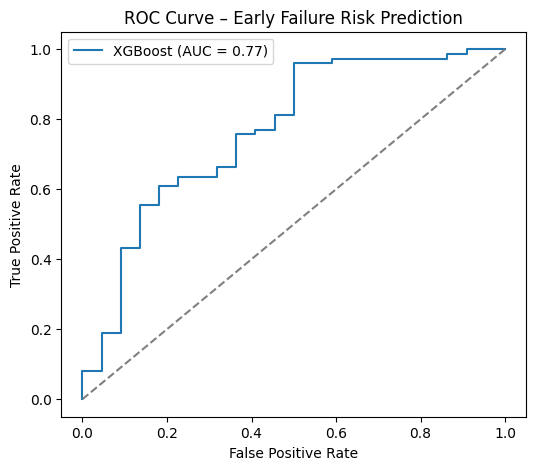

In [20]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='XGBoost (AUC = 0.77)')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Early Failure Risk Prediction")
plt.legend()
plt.show()


Because failure is defined conservatively and early signals are weak, the model prioritizes recall over precision. As a result, confusion matrices at low thresholds show many false positives, which is expected for an early-warning system.
Also , we are trying to predict failure very early, when information is limited, the model is designed to warn us about most potentially risky shows. This means it sometimes raises alarms for shows that eventually succeed, which is expected for an early-warning system.

Actual vs Predicted Failure Risk

In [21]:
risk_table = X_test.copy()
risk_table['predicted_risk'] = y_prob_xgb
risk_table['actual_failed'] = y_test.values

risk_table.sort_values('predicted_risk', ascending=False).head(10)


,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,cognitive_load,episode_duration_min,skip_intro,night_watch_safe,predicted_risk,actual_failed
243,5.000000,6.000000,6.333333,45.666667,3.333333,2.000000,7.000000,44.333333,0.333333,0.0,0.998001,1
138,5.000000,4.666667,8.000000,47.000000,4.000000,2.666667,7.000000,42.333333,0.666667,0.0,0.996995,1
62,3.666667,5.666667,4.333333,40.000000,3.000000,2.333333,7.666667,43.000000,0.666667,0.0,0.994011,1
317,6.000000,7.333333,5.666667,71.333333,2.666667,1.000000,5.000000,43.000000,0.333333,0.0,0.991574,1
456,3.666667,7.666667,5.000000,56.000000,3.000000,0.333333,7.000000,126.666667,0.000000,0.0,0.991534,1
426,3.666667,5.666667,5.666667,51.333333,3.666667,3.000000,7.000000,81.666667,0.333333,0.0,0.990857,1
347,4.333333,3.666667,7.333333,39.666667,4.000000,2.333333,7.666667,7.000000,0.666667,0.0,0.989848,0
472,4.333333,6.000000,7.000000,53.666667,2.666667,1.333333,6.333333,42.666667,0.666667,0.0,0.989716,1
376,5.000000,7.666667,6.333333,68.000000,3.000000,1.333333,5.666667,42.333333,0.000000,0.0,0.989076,1
194,4.333333,5.333333,6.666667,47.666667,3.000000,3.000000,7.666667,56.000000,0.666667,0.0,0.988373,1


Confusion matrix

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

for t in [0.3, 0.4, 0.5]:
    preds = (y_prob_xgb >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))



Threshold = 0.3
[[ 3 19]
 [ 1 73]]
              precision    recall  f1-score   support

           0       0.75      0.14      0.23        22
           1       0.79      0.99      0.88        74

    accuracy                           0.79        96
   macro avg       0.77      0.56      0.56        96
weighted avg       0.78      0.79      0.73        96


Threshold = 0.4
[[ 6 16]
 [ 2 72]]
              precision    recall  f1-score   support

           0       0.75      0.27      0.40        22
           1       0.82      0.97      0.89        74

    accuracy                           0.81        96
   macro avg       0.78      0.62      0.64        96
weighted avg       0.80      0.81      0.78        96


Threshold = 0.5
[[ 8 14]
 [ 2 72]]
              precision    recall  f1-score   support

           0       0.80      0.36      0.50        22
           1       0.84      0.97      0.90        74

    accuracy                           0.83        96
   macro avg       0

Choosing a threshold(0.4) that preserves high recall for failures while reducing unnecessary false alarms, balancing early warning with practical usability.

In [23]:
preds = (y_prob_xgb >= 0.4).astype(int)
print(f"\nThreshold = 0.4")
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))


Threshold = 0.4
[[ 6 16]
 [ 2 72]]
              precision    recall  f1-score   support

           0       0.75      0.27      0.40        22
           1       0.82      0.97      0.89        74

    accuracy                           0.81        96
   macro avg       0.78      0.62      0.64        96
weighted avg       0.80      0.81      0.78        96



Analyze Feature Importance from XGBoost

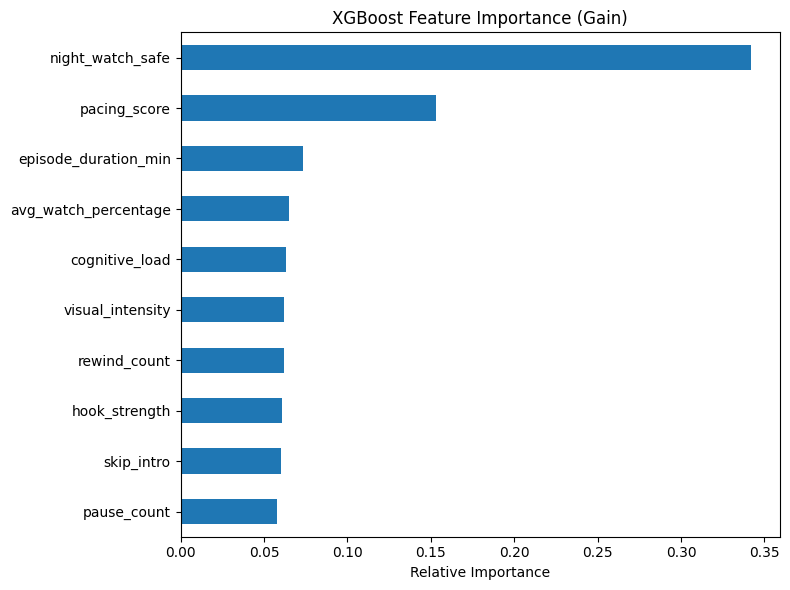

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,6))
xgb_importance.plot(kind='barh')
plt.title("XGBoost Feature Importance (Gain)")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


# **Intervention Recommendation System**

In [25]:
# Initialize column
model_df['predicted_risk'] = None

# Assign XGBoost predicted probabilities ONLY to test-set rows
model_df.loc[X_test.index, 'predicted_risk'] = y_prob_xgb

model_df.head()


,show_id,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,cognitive_load,episode_duration_min,skip_intro,night_watch_safe,drop_off,drop_off_probability,failed,predicted_risk
0,36,5.666667,8.333333,4.666667,65.333333,2.000000,2.333333,6.333333,43.333333,0.000000,0.0,0.0,0.391000,1,None
1,40,7.000000,6.666667,5.333333,65.333333,1.333333,1.666667,5.666667,45.000000,0.333333,0.0,0.0,0.389000,0,None
2,45,6.000000,5.333333,5.333333,61.000000,1.666667,1.666667,5.666667,60.000000,0.666667,0.0,0.0,0.432333,0,0.786803
3,52,6.666667,6.333333,6.666667,65.000000,2.666667,3.000000,5.333333,23.000000,0.333333,0.0,0.0,0.399333,1,None
4,90,6.000000,6.666667,7.333333,61.666667,3.333333,1.000000,6.333333,45.000000,0.333333,0.0,0.0,0.446000,1,None


In [26]:
def assign_risk_bucket(p):
    if pd.isna(p):
        return None
    elif p < 0.3:
        return 'Low Risk'
    elif p < 0.4:
        return 'Medium Risk'
    else:
        return 'High Risk'

model_df['risk_bucket'] = model_df['predicted_risk'].apply(assign_risk_bucket)

model_df.head()

,show_id,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,cognitive_load,episode_duration_min,skip_intro,night_watch_safe,drop_off,drop_off_probability,failed,predicted_risk,risk_bucket
0,36,5.666667,8.333333,4.666667,65.333333,2.000000,2.333333,6.333333,43.333333,0.000000,0.0,0.0,0.391000,1,None,None
1,40,7.000000,6.666667,5.333333,65.333333,1.333333,1.666667,5.666667,45.000000,0.333333,0.0,0.0,0.389000,0,None,None
2,45,6.000000,5.333333,5.333333,61.000000,1.666667,1.666667,5.666667,60.000000,0.666667,0.0,0.0,0.432333,0,0.786803,High Risk
3,52,6.666667,6.333333,6.666667,65.000000,2.666667,3.000000,5.333333,23.000000,0.333333,0.0,0.0,0.399333,1,None,None
4,90,6.000000,6.666667,7.333333,61.666667,3.333333,1.000000,6.333333,45.000000,0.333333,0.0,0.0,0.446000,1,None,None


In [27]:
model_df[['predicted_risk', 'risk_bucket']].head(10)


,predicted_risk,risk_bucket
0,None,None
1,None,None
2,0.786803,High Risk
3,None,None
4,None,None
5,0.795606,High Risk
6,None,None
7,None,None
8,0.980945,High Risk
9,None,None


In [28]:
# Select successful low-risk shows (only where prediction exists)
successful_shows = model_df[
    (model_df['risk_bucket'] == 'Low Risk') &
    (model_df['failed'] == 0)
]

# Compute baseline early engagement profile
success_baseline = successful_shows[final_features].mean()

success_baseline


,0
pacing_score,7.222222
hook_strength,6.666667
visual_intensity,5.222222
avg_watch_percentage,69.222222
pause_count,1.777778
rewind_count,1.666667
cognitive_load,5.666667
episode_duration_min,36.555556
skip_intro,0.222222
night_watch_safe,0.000000


In [29]:
high_risk_shows = model_df[
    model_df['risk_bucket'] == 'High Risk'
]

high_risk_shows.shape


(88, 16)

In [30]:
# Pick one high-risk show for demonstration
sample_show = high_risk_shows.iloc[0]

# Extract its early engagement features
sample_features = sample_show[final_features]

# Compute gap relative to successful baseline
feature_gap = sample_features - success_baseline

# Sort by most underperforming features
feature_gap = feature_gap.sort_values()

feature_gap


,0
avg_watch_percentage,-8.222222
hook_strength,-1.333333
pacing_score,-1.222222
pause_count,-0.111111
rewind_count,0.0
cognitive_load,0.0
night_watch_safe,0.0
visual_intensity,0.111111
skip_intro,0.444444
episode_duration_min,23.444444


In [31]:
intervention_map = {
    'hook_strength': "Strengthen early narrative hooks to capture viewer attention.",
    'cognitive_load': "Reduce exposition density and simplify early plot elements.",
    'pacing_score': "Improve pacing in early episodes to maintain engagement.",
    'avg_watch_percentage': "Revise opening sequences to reduce early disengagement.",
    'episode_duration_min': "Consider shortening episode length to improve retention.",
    'skip_intro': "Rework the intro to better align with viewer expectations.",
    'visual_intensity': "Enhance visual engagement in early scenes."
}

recommendations = []

for feature, gap in feature_gap.items():
    if gap < 0 and feature in intervention_map:
        recommendations.append(intervention_map[feature])

recommendations


['Revise opening sequences to reduce early disengagement.',
 'Strengthen early narrative hooks to capture viewer attention.',
 'Improve pacing in early episodes to maintain engagement.']

In [32]:
print("Recommended Interventions for High-Risk Show:\n")

for r in recommendations:
    print("-", r)


Recommended Interventions for High-Risk Show:

- Revise opening sequences to reduce early disengagement.
- Strengthen early narrative hooks to capture viewer attention.
- Improve pacing in early episodes to maintain engagement.


In [33]:
baseline_std = successful_shows[final_features].std()


In [34]:
def generate_interventions(
    show_row,
    baseline_mean,
    baseline_std,
    features,
    intervention_map,
    top_k=1   # <-- THIS is the key change
):
    # Use only features with non-zero variance
    safe_features = [f for f in features if baseline_std[f] > 0]

    # Compute standardized gaps
    z_gaps = (show_row[safe_features] - baseline_mean[safe_features]) / baseline_std[safe_features]

    # Sort by most negative (most underperforming)
    worst_features = z_gaps.sort_values().head(top_k)

    recommendations = []
    for feature in worst_features.index:
        if feature in intervention_map:
            recommendations.append(intervention_map[feature])

    return recommendations


In [35]:
intervention_rows = []

for _, row in high_risk_shows.iterrows():
    recs = generate_interventions(
        show_row=row,
        baseline_mean=success_baseline,
        baseline_std=baseline_std,
        features=final_features,
        intervention_map=intervention_map,
        top_k=3
    )

    intervention_rows.append({
        'show_id': row['show_id'],
        'predicted_risk': row['predicted_risk'],
        'risk_bucket': row['risk_bucket'],
        'recommended_interventions': "; ".join(recs)
    })

intervention_df = pd.DataFrame(intervention_rows)
intervention_df.head(10)


,show_id,predicted_risk,risk_bucket,recommended_interventions
0,45,0.786803,High Risk,Revise opening sequences to reduce early disen...
1,95,0.795606,High Risk,Improve pacing in early episodes to maintain e...
2,121,0.980945,High Risk,Revise opening sequences to reduce early disen...
3,693,0.987657,High Risk,Revise opening sequences to reduce early disen...
4,1400,0.889204,High Risk,Improve pacing in early episodes to maintain e...
5,1407,0.768169,High Risk,Revise opening sequences to reduce early disen...
6,1408,0.987948,High Risk,Revise opening sequences to reduce early disen...
7,1413,0.960165,High Risk,Revise opening sequences to reduce early disen...
8,1416,0.966664,High Risk,Revise opening sequences to reduce early disen...
9,1419,0.943079,High Risk,Improve pacing in early episodes to maintain e...


In [36]:
intervention_df = intervention_df.sort_values(
    by='predicted_risk',
    ascending=False
)

intervention_df.head(10)


,show_id,predicted_risk,risk_bucket,recommended_interventions
43,58841,0.998001,High Risk,Revise opening sequences to reduce early disen...
23,4607,0.996995,High Risk,Revise opening sequences to reduce early disen...
11,1435,0.994011,High Risk,Revise opening sequences to reduce early disen...
60,79593,0.991574,High Risk,Improve pacing in early episodes to maintain e...
83,274556,0.991534,High Risk,Revise opening sequences to reduce early disen...
77,242551,0.990857,High Risk,Revise opening sequences to reduce early disen...
68,95897,0.989848,High Risk,Revise opening sequences to reduce early disen...
85,292035,0.989716,High Risk,Revise opening sequences to reduce early disen...
71,125364,0.989076,High Risk,Improve pacing in early episodes to maintain e...
35,33907,0.988373,High Risk,Revise opening sequences to reduce early disen...


## Limitations and Assumptions

- Early-episode engagement captures only initial viewer behavior and may not fully reflect long-term retention dynamics.

- Failure labels are proxy indicators derived from engagement metrics rather than explicit user intent, which may introduce noise in the ground truth.

- The model is intentionally optimized for higher recall to function as an early-warning system. This leads to increased false positives, which is acceptable for exploratory and decision-support use cases, but unsuitable for fully automated or high-stakes decisions.
